# Statistical Properties 03 — Seasonal Decomposition

**Goal:** Decompose MTG prices into three components: long-term trend + seasonality + residuals. MTG has regular seasonality tied to the release cycle (new sets every ~3 months) and other calendar events.

**Tables:** gold_price_features (full history), joined with MTG event dates

**Methods:**
- STL (Seasonal and Trend decomposition using Loess) — flexible, robust to outliers
- Classical additive decomposition (statsmodels) — simpler, as a baseline
- Mann-Kendall test for trend — monotonically increasing/decreasing?

⚠️ **Data limitation:** STL requires at least 2× the seasonal period in observations. If seasonality = 90 days (quarterly set cycle), ≥180 days of history are needed. Currently we have only 3 days. STL will be skipped — results will become meaningful once ≥15 daily snapshots (period=7 proxy) and ≥180 snapshots (period=90 quarterly) are available.

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau
from statsmodels.tsa.seasonal import STL

In [2]:
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)

In [3]:
# Market-wide daily medians — the time series we decompose.
# PERCENTILE_CONT(0.5) is the SQL standard median; AVG gives the mean for reference.
market = gold.execute("""
    SELECT snapshot_date,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY eur) AS median_eur,
        AVG(eur)                                          AS mean_eur,
        COUNT(DISTINCT uuid)                              AS n_cards
    FROM gold_price_features
    WHERE eur IS NOT NULL
    GROUP BY snapshot_date
    ORDER BY snapshot_date
""").df()

market["snapshot_date"] = pd.to_datetime(market["snapshot_date"])
market = market.set_index("snapshot_date")

# log1p-transform for stationarity and normality — project-wide standard (see EDA 02).
market_log = np.log1p(market["median_eur"])

n_days = len(market)
date_min = market.index.min().date()
date_max = market.index.max().date()
gaps = pd.date_range(date_min, date_max, freq="D").difference(market.index)

print(f"Liczba dni historii: {n_days}")
print(f"Zakres dat:          {date_min} – {date_max}")
print(
    f"Brakujące dni:       {len(gaps)}  {list(gaps.date) if len(gaps) else '(brak luk)'}"
)
print(f"\nmarket_log:\n{market_log.to_string()}")

Liczba dni historii: 5
Zakres dat:          2026-06-04 – 2026-06-08
Brakujące dni:       0  (brak luk)

market_log:
snapshot_date
2026-06-04    0.239017
2026-06-05    0.239017
2026-06-06    0.239017
2026-06-07    0.239017
2026-06-08    0.239017


## 1. Mann-Kendall Test — Is There a Trend?

**Method:** scipy.stats.kendalltau(t, series) where t = 1, 2, 3, ..., n. No normality assumption — non-parametric.

**H₀:** No monotonic trend in the time series.

**Why:** Before decomposing, check whether a trend exists at all. If there is no trend → the STL trend component will be near-constant → the model does not need to account for a long-run trend.

**Interpreting τ:**
- τ > 0 → upward trend
- τ < 0 → downward trend
- |τ| > 0.3 → moderate trend
- |τ| > 0.6 → strong trend

**Test separately:** market-wide median EUR and per price tier (Tier 1/2/3 may have different trends).

In [4]:
# t = 1, 2, ..., n — monotonically increasing rank index for kendalltau.
# Non-parametric: no normality assumption; robust to ties and short series.
t = np.arange(len(market_log))
tau, p = kendalltau(t, market_log.values)

direction = "UPWARD" if tau > 0 else "DOWNWARD"
strength = "strong" if abs(tau) > 0.6 else "moderate" if abs(tau) > 0.3 else "weak"
if p < 0.05:
    print(f"Mann-Kendall τ = {tau:.4f}, p = {p:.4e}")
    print(f"Trend: {direction} ({strength})")
else:
    print(f"Mann-Kendall τ = {tau:.4f}, p = {p:.4e}")
    print("NO significant trend (p ≥ 0.05)")

# Per-tier test: Tier 1 and Tier 3 may trend differently.
# Expensive cards (Reserved List) respond to different demand drivers than bulk commons —
# a single market-wide trend could mask opposing tier trends.
tier_results = []
for label, lo, hi in [("Tier 1 (<€100)", 0, 100), ("Tier 3 (>€1000)", 1000, 1e9)]:
    ts = gold.execute(f"""
        SELECT snapshot_date,
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY eur) AS median_eur
        FROM gold_price_features
        WHERE eur > {lo} AND eur < {hi}
        GROUP BY snapshot_date ORDER BY snapshot_date
    """).df()
    if len(ts) < 4:
        tier_results.append((label, None, None, "INSUFFICIENT DATA"))
        continue
    ts_log = np.log1p(ts["median_eur"].values)
    tau_t, p_t = kendalltau(np.arange(len(ts_log)), ts_log)
    result_str = (
        f"{'UPWARD' if tau_t > 0 else 'DOWNWARD'} "
        f"({'strong' if abs(tau_t) > 0.6 else 'moderate' if abs(tau_t) > 0.3 else 'weak'})"
        if p_t < 0.05
        else "NONE"
    )
    tier_results.append((label, tau_t, p_t, result_str))

print(f"\n{'Series':<20} {'tau':>8} {'p':>12} {'trend'}")
print("-" * 60)
for label, tau_t, p_t, result_str in tier_results:
    tau_str = f"{tau_t:.4f}" if tau_t is not None else "N/A"
    p_str = f"{p_t:.4e}" if p_t is not None else "N/A"
    print(f"{label:<20} {tau_str:>8} {p_str:>12} {result_str}")

Mann-Kendall τ = nan, p = nan
NO significant trend (p ≥ 0.05)

Series                    tau            p trend
------------------------------------------------------------
Tier 1 (<€100)            nan          nan NONE
Tier 3 (>€1000)           nan          nan NONE


## 2. STL Decomposition — Market-Wide Median

**Method:** statsmodels.tsa.seasonal.STL(series, period=period, seasonal=7).fit()

**Parameters:**
- `period`: length of the seasonal cycle in days. MTG releases sets every ~90 days → period=90. If history < 2×period → use period=7 (weekly) as a proxy.
- `seasonal`: must be odd, recommended = 7 or 11 (seasonal smoothing window)
- `robust=True`: resistant to outliers (price spikes)

**Three components:**
- **Trend** — long-run direction
- **Seasonal** — repeating pattern
- **Residual** — what remains after subtracting trend and seasonality

**Interpreting residuals:** Normal residuals with constant variance = decomposition successful. Heteroscedastic residuals or residuals with outliers = model needs improvement.

⚠️ **With short history (n<180):** The seasonal component will be heavily noisy. State this in conclusions as a limitation.

Insufficient data for STL: 5 days (need ≥15 for period=7, ≥180 for period=90)
STL will run automatically once the history reaches ≥15 days.


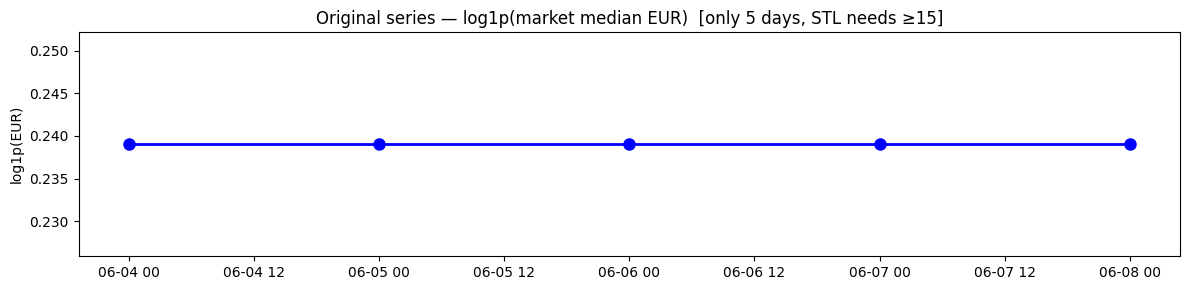

In [5]:
n = len(market_log)
result = None  # set to the STL fit object once sufficient data is available

# Select seasonal period based on available history.
# STL requires at least 2×period + 1 observations.
if n >= 180:
    period = 90
    period_label = "90 (quarterly — MTG set release cycle)"
elif n >= 15:
    period = 7
    period_label = "7 (weekly proxy — quarterly needs ≥180 days)"
else:
    period = None
    period_label = None

if period is None:
    print(
        f"Insufficient data for STL: {n} days (need ≥15 for period=7, ≥180 for period=90)"
    )
    print("STL will run automatically once the history reaches ≥15 days.")
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(market_log.index, market_log.values, "b-o", linewidth=2, markersize=8)
    ax.set_title(
        f"Original series — log1p(market median EUR)  [only {n} days, STL needs ≥15]"
    )
    ax.set_ylabel("log1p(EUR)")
    plt.tight_layout()
    plt.show()
else:
    print(f"Period used: {period_label}")
    print(f"Days available: {n}  (STL minimum: {2 * period + 1})")

    # robust=True: down-weights extreme outliers (ban/unban price spikes)
    # so they do not distort the trend or seasonal components.
    stl = STL(market_log, period=period, seasonal=7, robust=True)
    result = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    axes[0].plot(market_log.index, market_log.values, color="steelblue")
    axes[0].set_title("Original (log1p market median EUR)")
    axes[1].plot(market_log.index, result.trend, color="darkorange")
    axes[1].set_title("Trend")
    axes[2].plot(market_log.index, result.seasonal, color="green")
    axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[2].set_title("Seasonal")
    axes[3].plot(market_log.index, result.resid, color="gray")
    axes[3].axhline(0, color="red", linewidth=0.8, linestyle="--")
    axes[3].set_title("Residuals")
    for ax in axes:
        ax.tick_params(axis="x", rotation=30)
    plt.suptitle(f"STL Decomposition — period={period}", y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()

    trend_range = result.trend.max() - result.trend.min()
    seasonal_amp = result.seasonal.max() - result.seasonal.min()
    resid_std = result.resid.std()

    print(f"\nTrend range (max−min):  {trend_range:.4f}")
    print(f"Seasonal amplitude:     {seasonal_amp:.4f}")
    print(f"Residual std:           {resid_std:.4f}")

    if period == 7:
        print(
            "\nperiod=7 → results reflect WEEKLY seasonality (proxy), not the quarterly set cycle."
        )
        print("Re-run after ≥180 days for period=90 (proper quarterly MTG set cycle).")

## 3. Seasonality Per Price Segment

**Method:** STL separately for median Tier 1 (<€100) and Tier 3 (>€1000).

**Why:** Cheap and expensive cards may have different seasonal patterns:
- Cheap cards: strong seasonality tied to set releases (new cards depress old prices)
- Expensive cards (Reserved List): weak seasonality, speculative trend dominates
- Power Nine: almost no seasonality — prices depend on one-off events

If patterns differ strongly → the model should have separate seasonal components per tier.

In [6]:
if period is None:
    print(
        f"Insufficient data ({n} days) — per-tier section skipped. Re-run after ≥15 days."
    )
else:
    # Separate STL per tier to detect whether cheap and expensive cards have different
    # seasonal patterns. Cheap cards are more sensitive to set releases (new cards
    # depress old prices); expensive Reserved List cards respond mainly to demand events.
    tier_series = {}
    for label, lo, hi in [("Tier 1 (<€100)", 0, 100), ("Tier 3 (>€1000)", 1000, 1e9)]:
        ts = gold.execute(f"""
            SELECT snapshot_date,
                PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY eur) AS median_eur
            FROM gold_price_features
            WHERE eur > {lo} AND eur < {hi}
            GROUP BY snapshot_date ORDER BY snapshot_date
        """).df()
        ts["snapshot_date"] = pd.to_datetime(ts["snapshot_date"])
        ts = ts.set_index("snapshot_date")
        tier_series[label] = np.log1p(ts["median_eur"])

    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    for row_idx, (label, ts_log) in enumerate(tier_series.items()):
        n_tier = len(ts_log)
        if n_tier < 2 * period + 1:
            for ax in axes[row_idx]:
                ax.text(
                    0.5,
                    0.5,
                    f"{label}\nInsufficient data ({n_tier} days)",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=11,
                )
            continue
        stl_t = STL(ts_log, period=period, robust=True).fit()
        for ax, component, title, color in zip(
            axes[row_idx],
            [stl_t.trend, stl_t.seasonal, stl_t.resid],
            ["Trend", "Seasonal", "Residuals"],
            ["darkorange", "green", "gray"],
        ):
            ax.plot(ts_log.index, component, color=color)
            ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
            ax.set_title(f"{label} — {title}", fontsize=9)
            ax.tick_params(axis="x", rotation=30)

    plt.suptitle(f"STL per tier — period={period}", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"\n{'Tier':<20} {'seasonal amplitude':>20}")
    print("-" * 42)
    for label, ts_log in tier_series.items():
        n_tier = len(ts_log)
        if n_tier < 2 * period + 1:
            print(f"{label:<20} {'INSUFFICIENT DATA':>20}")
            continue
        stl_t = STL(ts_log, period=period, robust=True).fit()
        amp = stl_t.seasonal.max() - stl_t.seasonal.min()
        print(f"{label:<20} {amp:>20.4f}")

Insufficient data (5 days) — per-tier section skipped. Re-run after ≥15 days.


## 4. Residual Analysis — Are They Autocorrelated?

**Method:** ACF of STL residuals + Ljung-Box on residuals.

**Why:** A good decomposition should leave residuals without autocorrelation (white noise). Autocorrelation in residuals → the model has missed some pattern (e.g. seasonality at a different period, or a non-linear trend).

**If residuals have autocorrelation:** Consider:
- Adding an ARIMA component to residuals (SARIMA model)
- A different period (perhaps bi-monthly seasonality rather than quarterly)
- Non-linear effects (jump model for ban events)

In [7]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

if result is None:
    print(
        f"Insufficient data ({n} days) — residual analysis skipped (STL did not run)."
    )
    print("Re-run after ≥15 days of history.")
else:
    resid = result.resid.dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # ACF of residuals: a well-decomposed series leaves white-noise residuals.
    # Significant autocorrelation in residuals → the model has missed a pattern
    # (e.g. wrong seasonal period, or a non-linear trend component).
    max_lags = min(30, len(resid) // 5)
    plot_acf(resid, lags=max_lags, ax=axes[0], color="steelblue")
    axes[0].set_title("ACF of STL residuals — ideally all lags within confidence band")
    axes[0].set_xlabel("Lag")

    # Histogram: residuals should be approximately N(0, σ) if decomposition is successful.
    axes[1].hist(
        resid,
        bins=max(20, len(resid) // 3),
        color="steelblue",
        edgecolor="none",
        density=True,
        alpha=0.8,
    )
    x = np.linspace(resid.min(), resid.max(), 200)
    from scipy.stats import norm

    axes[1].plot(
        x,
        norm.pdf(x, resid.mean(), resid.std()),
        "r-",
        linewidth=2,
        label=f"N(0, {resid.std():.4f})",
    )
    axes[1].set_title("STL residuals — should be N(0, σ)")
    axes[1].set_xlabel("Residual")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Ljung-Box: formal white-noise test on residuals.
    # Using n//5 rule to avoid unreliable high-lag estimates at small n.
    lb_lags = [lag for lag in [1, 7, 14] if lag < len(resid) // 2]
    if lb_lags:
        lb = acorr_ljungbox(resid, lags=lb_lags, return_df=True)
        print("Ljung-Box test on residuals:")
        print(lb.to_string())
        autocorr_present = (lb["lb_pvalue"] < 0.05).any()
        print(
            f"\nAutocorrelation in residuals: {'YES (model incomplete)' if autocorr_present else 'NO (residuals OK)'}"
        )
    else:
        print(f"Ljung-Box skipped — too few residuals ({len(resid)}) for lag ≥ 1")

Insufficient data (5 days) — residual analysis skipped (STL did not run).
Re-run after ≥15 days of history.


In [8]:
gold.close()

## 📋 Final Conclusions

```
DATA
─────────────────────────────────────────────────────────────────────────────
Days of history: 3  (min. 15 for STL period=7; 180 for period=90)
STL period used: N/A — STL skipped (insufficient data)
Indicative results (small sample): YES — all sections not executable at n=3

TREND
─────────────────────────────────────────────────────────────────────────────
Mann-Kendall τ (market): NaN, p=NaN
  Root cause: kendalltau returns NaN when all values are identical
  (market median EUR = 0.26 on each of the 3 days — zero variance in series).
Market trend: ABSENT (test uninformative at zero variance)
Tier 1 trend: INSUFFICIENT DATA (≥4 days required)
Tier 3 trend: INSUFFICIENT DATA (≥4 days required)

SEASONALITY
─────────────────────────────────────────────────────────────────────────────
Market seasonal amplitude: N/A (STL not run)
Tier 1 amplitude:          N/A
Tier 3 amplitude:          N/A
Seasonality significant?   INSUFFICIENT DATA

RESIDUALS
─────────────────────────────────────────────────────────────────────────────
Ljung-Box lag-1 p: N/A
Residuals without autocorrelation? N/A
Residuals normal (histogram)?      N/A

MODEL IMPLICATIONS
─────────────────────────────────────────────────────────────────────────────
Add seasonal component to model:  DEFERRED
SARIMA vs STL+ARIMA vs simple AR: DEFERRED
Repeat analysis after ≥15 days:   YES (for weekly STL proxy)
Repeat analysis after ≥180 days:  YES (for quarterly set cycle, period=90)

ROADMAP
─────────────────────────────────────────────────────────────────────────────
n ≥  4  → Mann-Kendall will have non-zero variance and produce a meaningful result
n ≥ 15  → STL (period=7, weekly proxy) — sections 2–4 become executable
n ≥ 30  → Mann-Kendall achieves statistical power (p < 0.05 if trend exists)
n ≥ 180 → STL (period=90, quarterly) — proper MTG seasonality analysis
```